# Import packages

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from igor2 import binarywave as bw
import glob
import pickle
from pathlib import Path
from matplotlib.transforms import Bbox
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import TwoSlopeNorm
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter1d
import re
from scipy.interpolate import RBFInterpolator

In [4]:
from scipy.fftpack import fft2, ifft2, fftshift
from scipy.stats import binned_statistic
from scipy.stats import binned_statistic
from scipy.ndimage import gaussian_filter, maximum_filter, minimum_filter
import matplotlib.patches as patches

from scipy.spatial import Voronoi
from skimage.filters import gaussian
from skimage.feature import peak_local_max
from skimage.morphology import disk
from shapely.geometry import Polygon

In [5]:
import warnings
warnings.filterwarnings('ignore')

## Data preparation

In [6]:
def flatten_image(image, order=1, axis=1):

    flattened_image = np.copy(image)

    num_lines = image.shape[axis]
    length = image.shape[1 - axis]
    x = np.arange(length)

    for i in range(num_lines):
        line = image[i, :] if axis == 0 else image[:, i]
        coeffs = np.polyfit(x, line, deg=order)
        fit_line = np.polyval(coeffs, x)

        if axis == 0:
            flattened_image[i, :] = line - fit_line
        else:
            flattened_image[:, i] = line - fit_line

    return flattened_image

def normalizer(img):
    img = np.asarray(img, dtype=float)
    return (img - np.min(img)) / (np.max(img) - np.min(img) + 1e-12)

# Define once
red_white_blue = LinearSegmentedColormap.from_list(
    "red_white_blue",
    ["blue", "white", "red"]
)

## Grid analysis

In [15]:
with open("auconi_mfm_grid.pkl", "rb") as f:
    data = pickle.load(f)


print(data.keys())

dict_keys(['positions', 'images'])


In [16]:
images = data["images"]
positions = data["positions"]

images = np.array(images[:23])
positions = np.array(positions[:23])  # overwrite the same variable

print(images.shape)
print(positions.shape)

(23, 5, 256, 256)
(23, 2)


vmin=-0.00, vcenter=0.00, vmax=0.00


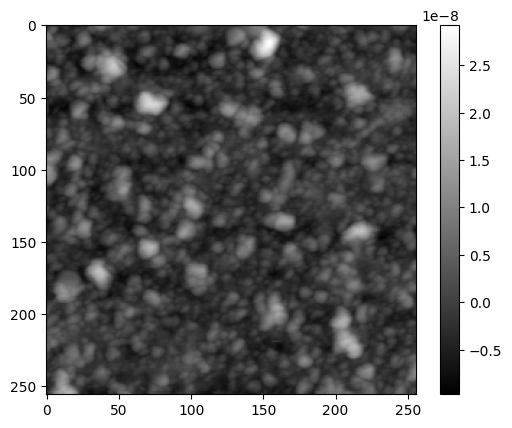

In [63]:
slice_img = images[22][0]

vmin = np.min(slice_img)
vmax = np.max(slice_img)
vcenter = (vmin + vmax) / 2      

# Create adaptive normalization
norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

print(f"vmin={vmin:.2f}, vcenter={vcenter:.2f}, vmax={vmax:.2f}")

plt.imshow(slice_img, cmap=red_white_blue, norm=norm)
plt.imshow(slice_img, cmap="gray")
plt.colorbar()
plt.show()

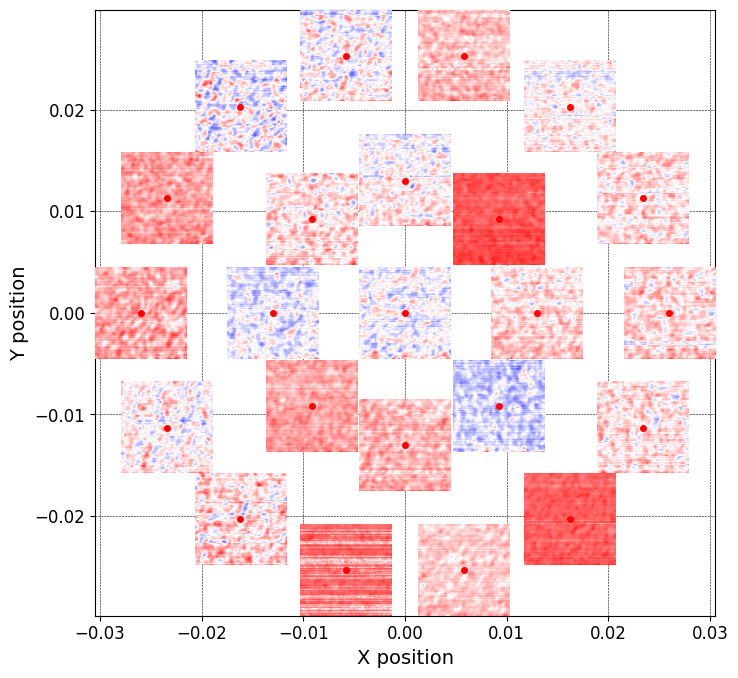

In [18]:
channel = 4   # choose which channel to display, e.g. 0 = height, 4 = MFM
scale = 0.009   # scaling factor for image size in plot units

fig, ax = plt.subplots(figsize=(8, 8))

for img, (x, y) in zip(images, positions):
    h, w = img[channel].shape
    
    # extent defines where each image is placed
    extent = [x - scale/2, x + scale/2, y - scale/2, y + scale/2]
    
    vmin = np.min(img[channel])
    vmax = np.max(img[channel])
    vcenter = (vmin + vmax) / 2      

    # Create adaptive normalization
    norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
    #ax.imshow(img[channel], cmap="grey", extent=extent, origin="lower", zorder=5)
    ax.imshow(img[channel], cmap=red_white_blue, norm=norm, extent=extent, origin="upper", zorder=5)
    
    ax.plot(x, y, "ro", markersize=4, zorder=10)  # optional: mark center with red dot

ax.set_aspect("equal")
ax.grid(True, color="black", linestyle="--", linewidth=0.4, zorder=0)


ax.set_xlabel("X position", fontsize=14)
ax.set_ylabel("Y position", fontsize=14)
ax.tick_params(axis = "both", labelsize = 12)

#plt.savefig(out_dir / "GT_MagneticResponces_as_deposit_Realmap.png",  dpi = 300, bbox_inches = "tight", pad_inches = 0)
plt.show()


## Correlation length

In [20]:
def _radial_profile(arr):
    H, W = arr.shape
    cy, cx = H//2, W//2
    y, x = np.indices(arr.shape)
    r = np.sqrt((y-cy)**2 + (x-cx)**2)
    r_flat = r.ravel()
    a_flat = arr.ravel()
    bins = np.arange(0, r_flat.max()+1)  # 1 px bins
    prof, edges, _ = binned_statistic(r_flat, a_flat, statistic='mean', bins=bins)
    centers = 0.5*(edges[:-1] + edges[1:])
    return centers, prof

def correlation_length_nm(height_img, pixel_size_nm,
                          smooth_sigma_px=3,
                          thresholds=(0.6, 0.2, 0.1)):
                            # 0.2 for mag
                            # 0.5 for hight

    I = np.asarray(height_img, dtype=float)
    if not np.isfinite(I).any():
        return np.nan

    # detrend: remove mean (you can also high-pass if there is a slow background)
    I = I - np.nanmean(I)

    # window to reduce FFT wrap-around artifacts
    wy = np.hanning(I.shape[0])[:, None]
    wx = np.hanning(I.shape[1])[None, :]
    W = wy * wx
    Iw = I * W

    # autocorrelation via Wiener–Khinchin
    F = fft2(Iw)
    P = np.abs(F)**2
    C = fftshift(np.real(ifft2(P)))

    # normalize by zero-lag value (center), not by global max
    cy, cx = C.shape[0]//2, C.shape[1]//2
    c0 = C[cy, cx]
    if not np.isfinite(c0) or c0 == 0:
        return np.nan
    Cn = C / c0

    # radial average -> C(r); smooth to suppress noise/oscillations
    r_px, Cr = _radial_profile(Cn)
    if Cr is None or not np.isfinite(Cr).any():
        return np.nan
    Cr = gaussian_filter1d(Cr, sigma=smooth_sigma_px)

    # find first crossing for any acceptable threshold
    for thr in thresholds:
        idx = np.where(Cr <= thr)[0]
        if idx.size > 0:
            i = idx[0]
            if i == 0:
                r_star_px = r_px[i]
            else:
                # linear interpolate between (i-1) and i
                y1, y2 = Cr[i-1], Cr[i]
                x1, x2 = r_px[i-1], r_px[i]
                if y2 == y1:
                    r_star_px = x2
                else:
                    t = (thr - y1)/(y2 - y1)
                    r_star_px = x1 + t*(x2 - x1)
            return float(r_star_px * pixel_size_nm)

    # no crossing found -> correlation length exceeds FOV; return NaN or FOV
    # return np.nan
    return float(min(I.shape) * pixel_size_nm)  # or comment this and return NaN


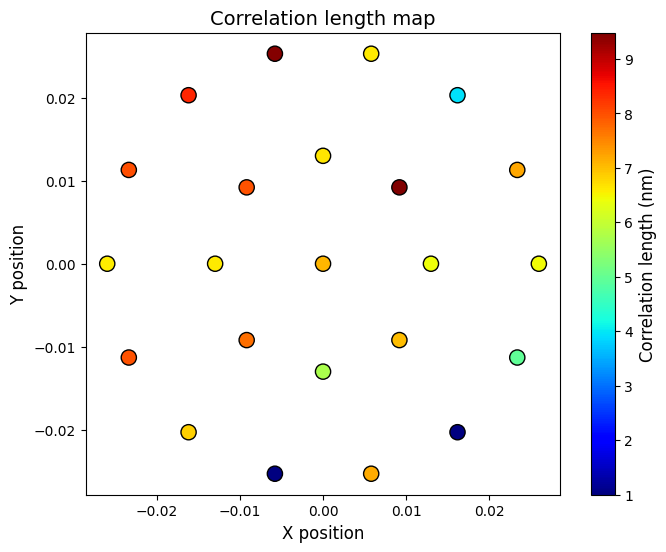

In [21]:
# --- set parameters ---
pixel_size_nm = 2   # change to your actual calibration!
channel = 4         # 0 = height, 4 = MFM phase, etc.

correlation_lengths = []

# --- run over all images ---
for img in images:
    L = correlation_length_nm(img[channel], pixel_size_nm=pixel_size_nm)
    correlation_lengths.append(L)

correlation_lengths = np.array(correlation_lengths)

# --- plot map ---
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    positions[:, 0], positions[:, 1],
    c=correlation_lengths, cmap="jet",
    s=120, edgecolor="k"
)

cb = plt.colorbar(sc, ax=ax)
cb.set_label("Correlation length (nm)", fontsize=12)

ax.set_xlabel("X position", fontsize=12)
ax.set_ylabel("Y position", fontsize=12)
ax.set_title("Correlation length map", fontsize=14)
ax.set_aspect("equal")

plt.show()

In [22]:
# Find indices of min and max correlation length
idx_max = np.nanargmax(correlation_lengths)   # ignore NaNs
idx_min = np.nanargmin(correlation_lengths)

# Values
L_max = correlation_lengths[idx_max]
L_min = correlation_lengths[idx_min]

# Corresponding positions
pos_max = positions[idx_max]
pos_min = positions[idx_min]

print(f"Max correlation length: {L_max:.2f} nm at index {idx_max}, position {pos_max}")
print(f"Min correlation length: {L_min:.2f} nm at index {idx_min}, position {pos_min}")


Max correlation length: 9.48 nm at index 2, position [0.0092 0.0092]
Min correlation length: 1.00 nm at index 19, position [-0.0058 -0.0253]


How the maxima look

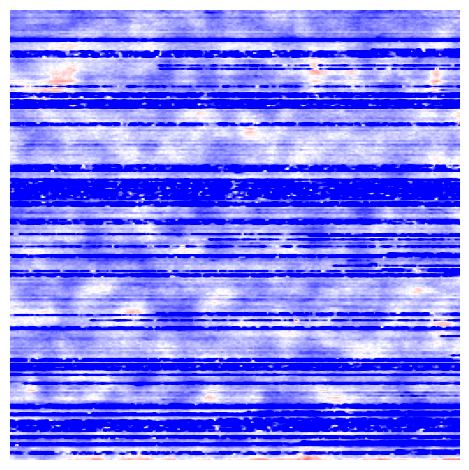

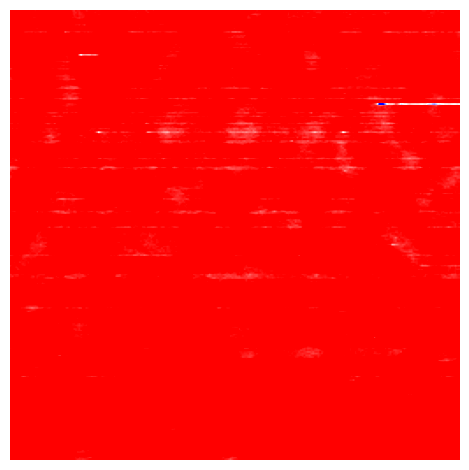

--------------------
Max corr length
9.48 nm
pos=[0.0092 0.0092], idx=2
--------------------
Min corr length
1.00 nm
pos=[-0.0058 -0.0253], idx=19


In [23]:
# Min image
#plt.imshow(images[idx_min][channel], cmap="grey")
plt.imshow(images[idx_min][channel], cmap=red_white_blue, norm=norm)

plt.axis("off")
# plt.savefig(out_dir / "min_mag_size_0.039 0._asd.png", dpi=300, bbox_inches='tight', pad_inches=0)
plt.tight_layout()
plt.show()

# Max image
#plt.imshow(images[idx_max][channel], cmap="grey")
plt.imshow(images[idx_max][channel], cmap=red_white_blue, norm=norm)
# axes[1].set_title(f"Max corr length\n{L_max:.2f} nm\npos={pos_max}, idx={idx_max}")
plt.axis("off")
# plt.savefig(out_dir / "max_mag_size_-0.039  0._asd.png", dpi=300, bbox_inches='tight', pad_inches=0)
plt.tight_layout()
plt.show()

print("-" * 20)
print(f"Max corr length\n{L_max:.2f} nm\npos={pos_max}, idx={idx_max}")

print("-" * 20)
print(f"Min corr length\n{L_min:.2f} nm\npos={pos_min}, idx={idx_min}")

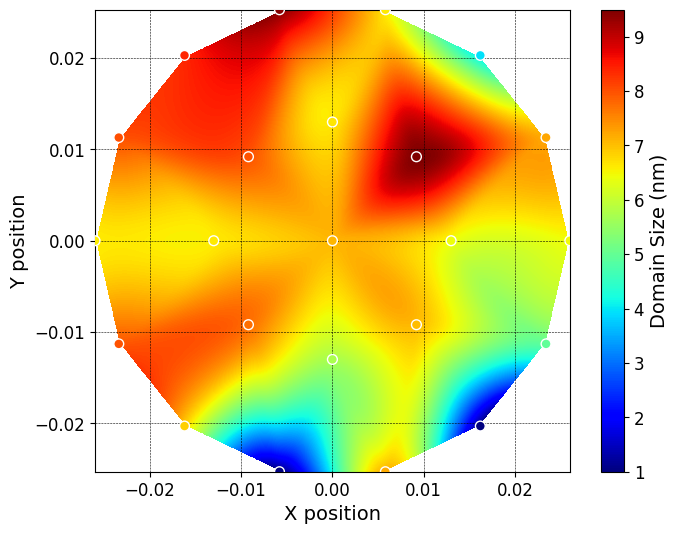

In [24]:
# Create a regular grid covering your positions
grid_x, grid_y = np.mgrid[
    positions[:,0].min():positions[:,0].max():2000j,   # 200 points along X
    positions[:,1].min():positions[:,1].max():2000j    # 200 points along Y
]

# Interpolate values onto the grid
grid_z = griddata(positions, correlation_lengths, (grid_x, grid_y), method="cubic")

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(grid_z.T, extent=(
        positions[:,0].min(), positions[:,0].max(),
        positions[:,1].min(), positions[:,1].max()
    ),
    origin="lower", cmap="jet", aspect="equal", zorder=1)

# Overlay measurement points
sc = ax.scatter(
    positions[:,0], positions[:,1],
    c=correlation_lengths,
    cmap="jet",
    edgecolor="w",
    s=50,
    zorder=5
)

# Colorbar
cb = plt.colorbar(im, ax=ax)
cb.set_label("Domain Size (nm)", fontsize=14)
cb.ax.tick_params(labelsize = 12)

ax.set_xlabel("X position", fontsize=14)
ax.set_ylabel("Y position", fontsize=14)
ax.tick_params(axis = "both", labelsize = 12)
# ax.set_title("GT_corr MAP length map", fontsize=14)
ax.grid(True, color="black", linestyle="--", linewidth=0.4, zorder=0)

#plt.savefig(out_dir / "GT_DomainSize_as_deposit.png",  dpi = 300, bbox_inches = "tight", pad_inches = 0)
plt.show()

